In [1]:
!pip install kaggle

Set Environment Variable

In [2]:
import json

kaggle_token = {
    "username": "mochamadrafi",
    "key": "KGAT_d00f7cd4de5031d980cf0d96cb43faa9"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_token, f)

In [3]:
!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

Test Dataset

In [4]:
!kaggle datasets list -s agriculture

ref                                                                    title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
aman2000jaiswal/agriculture-crop-images                                Agriculture crop images                              62575817  2021-03-10 16:56:50.653000          14159        283  0.9411765        
samuelotiattakorah/agriculture-crop-yield                              Agriculture Crop Yield                               35043399  2024-09-08 02:06:25.477000          11941        104  1.0              
imtkaggleteam/agriculture-dataset-karnataka                            Agriculture dataset | Karnataka                         42206  2024-12-16 09:07:02.877000           3450 

Download Dataset Smart Agriculture

In [5]:
!kaggle datasets download -d chaitanyagopidesi/smart-agriculture-dataset
!unzip smart-agriculture-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/chaitanyagopidesi/smart-agriculture-dataset
License(s): apache-2.0
  0% 0.00/66.1k [00:00<?, ?B/s]
100% 66.1k/66.1k [00:00<00:00, 214MB/s]
Archive:  smart-agriculture-dataset.zip
  inflating: cropdata_updated.csv    


Import Library & Load Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cropdata_updated.csv")
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


Data Understanding

In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


In [9]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Data Standardization (Renane Kolom)

In [10]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("Nama kolom setelah standardisasi:")
print(df.columns)

Nama kolom setelah standardisasi:
Index(['crop_id', 'soil_type', 'seedling_stage', 'moi', 'temp', 'humidity',
       'result'],
      dtype='object')


Tambahkan Timestamp Dummy (untuk Time Series)

In [11]:
end_time = pd.Timestamp.now()
start_time = end_time - pd.Timedelta(days=180)

timestamps = pd.to_datetime(
    np.random.uniform(start_time.value, end_time.value, len(df))
)

timestamps = np.sort(timestamps)

df["timestamp"] = timestamps

cols = ["timestamp"] + [c for c in df.columns if c != "timestamp"]
df = df[cols]

df.head()

,timestamp,crop_id,soil_type,seedling_stage,moi,temp,humidity,result
0,2025-09-08 01:30:37.731383296,Wheat,Black Soil,Germination,1,25,80.0,1
1,2025-09-08 01:32:43.278401024,Wheat,Black Soil,Germination,2,26,77.0,1
2,2025-09-08 01:55:02.674934784,Wheat,Black Soil,Germination,3,27,74.0,1
3,2025-09-08 02:12:50.342684416,Wheat,Black Soil,Germination,4,28,71.0,1
4,2025-09-08 02:21:48.889056768,Wheat,Black Soil,Germination,5,29,68.0,1


Hitung Data Quality Score

In [12]:
total_records = len(df)
total_cells = df.size

missing_values = df.isnull().sum().sum()

accuracy = 1 - (missing_values / total_cells)

non_null = df.notnull().sum().sum()
completeness = non_null / total_cells

end_date = pd.Timestamp.now()
thirty_days_ago = end_date - pd.Timedelta(days=30)

data_last_30_days = df[df["timestamp"] >= thirty_days_ago].shape[0]

timeliness = data_last_30_days / total_records

print("=== DATA QUALITY SCORE ===")

print(f"Accuracy      : {accuracy*100:.2f}%")
print(f"Completeness  : {completeness*100:.2f}%")
print(f"Timeliness    : {timeliness*100:.2f}%")

=== DATA QUALITY SCORE ===
Accuracy      : 100.00%
Completeness  : 100.00%
Timeliness    : 16.78%


Exploratory Visualization

📊 Exploratory Data Analysis (EDA)
--------------------------------------------------
📈 Visualisasi Distribusi Sensor...


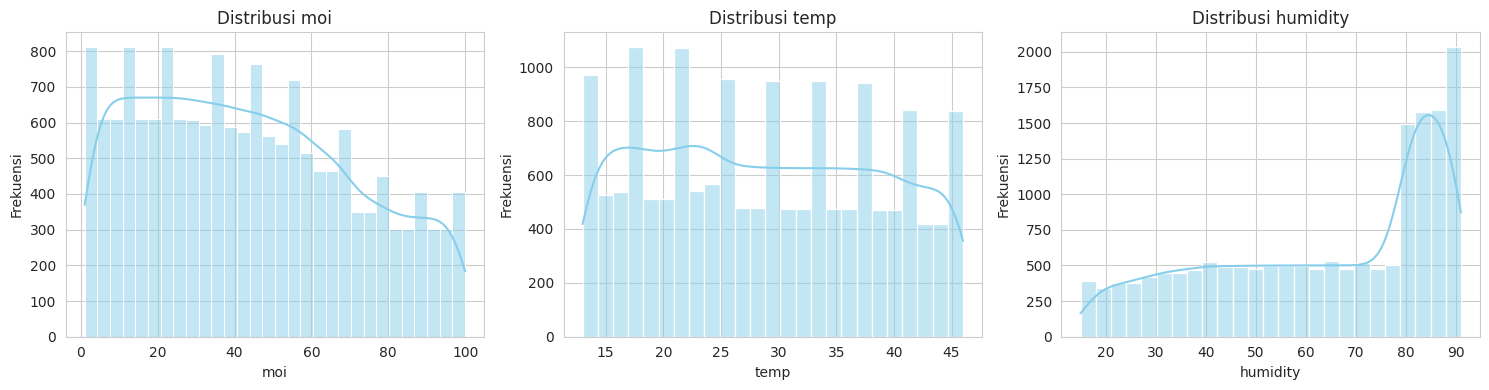

🔥 Analisis Korelasi Antar Variabel Sensor...


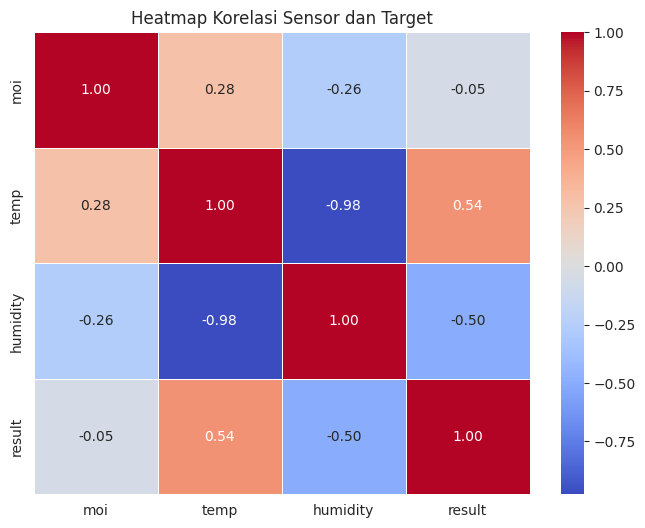

🌱 Analisis Proporsi Target (Irigasi vs Tidak)...


/tmp/ipykernel_503/3202570510.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


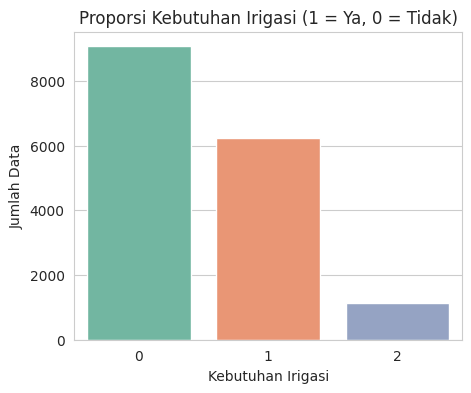

In [13]:
print("📊 Exploratory Data Analysis (EDA)")
print("-" * 50)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==============================
# Distribusi Variabel Numerik
# ==============================
print("📈 Visualisasi Distribusi Sensor...")

numeric_columns = ['moi', 'temp', 'humidity']

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for i, column in enumerate(numeric_columns):
    sns.histplot(
        df[column],
        kde=True,
        ax=axes[i],
        color='skyblue'
    )

    axes[i].set_title(f'Distribusi {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()


# ==============================
# Heatmap Korelasi
# ==============================
print("🔥 Analisis Korelasi Antar Variabel Sensor...")

plt.figure(figsize=(8,6))

correlation = df[['moi','temp','humidity','result']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Sensor dan Target")
plt.show()


# ==============================
# Distribusi Target
# ==============================
print("🌱 Analisis Proporsi Target (Irigasi vs Tidak)...")

plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x='result',
    palette='Set2'
)

plt.title("Proporsi Kebutuhan Irigasi (1 = Ya, 0 = Tidak)")
plt.xlabel("Kebutuhan Irigasi")
plt.ylabel("Jumlah Data")

plt.show()

Download Cleaned dataset.csv

In [15]:
df.to_csv("cleaned_data.csv", index=False)

from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>